In [185]:
import glob
import subprocess
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from concurrent.futures import ProcessPoolExecutor
import os, shutil
from tqdm import tqdm
import cv2
import warnings
import re
warnings.filterwarnings("ignore")
from xspec import Spectrum, Model, Fit, Xset, PlotManager, Plot, AllModels, AllData, Chain, AllChains, FakeitSettings
# import acx2_xspec

In [186]:
plt.style.use("default")
plt.rc('xtick', direction='in', top=True)
plt.rc('ytick', direction='in', right=True)
plt.rc('axes', linewidth=1.15)

size = 11
plt.rc("mathtext", fontset="dejavuserif")
plt.rc('font', family='DejaVu Serif', size=size)

In [187]:
modelname = 'TBabs(vpshock+po)'
modelname_safe = re.sub(r'[\*\+()]', '_', modelname)
if modelname_safe.endswith('_'):
    modelname_safe = modelname_safe[:-1]
Filename = f'SRC_{modelname_safe}'

Dir = '../Data/Spectra/'
srcfile='source_820_SourceSpec_00001_corr.fits'
bkgfile='background_820_SourceSpec_00001_corr.fits'

output_dir = os.path.join(Dir, "Fitting_Results", Filename)
os.makedirs(output_dir, exist_ok=True)
# plots_dir = os.path.join(output_dir, "Plots")
# mcmc_dir = os.path.join(output_dir, "MCMC_Results")
# os.makedirs(plots_dir, exist_ok=True)
# os.makedirs(mcmc_dir, exist_ok=True)

In [188]:
Xset.xsect = 'vern'
Xset.abund = 'wilm'
Fit.statMethod = 'cstat'
Xset.chatter = 1
Xset.allowPrompting = False

In [189]:
AllData.clear()
pwd = os.getcwd()
os.chdir(Dir)
sp_src = Spectrum(srcfile)
# src_response = sp_src.respons
src_rmf_file = sp_src.response.rmf
src_arf_file = sp_src.response.arf
sp_src.multiresponse[0].arf = src_arf_file
sp_src.multiresponse[1] = src_rmf_file
sp_src.multiresponse[1].arf = src_arf_file
sp_src.multiresponse[2] = src_rmf_file
os.chdir(pwd)

In [190]:
AllData.ignore("**-0.2,8.0-**")

In [191]:
Xset.chatter = 10
AllData.show()
Xset.chatter = 1


1 file 1 spectrum 
Spectrum 1  Spectral Data File: source_820_SourceSpec_00001_corr.fits
Net count rate (cts/s) for Spectrum:1  6.673e+01 +/- 5.730e-01
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  21-796
  Telescope: eROSITA Instrument: MERGED  Channel Type: PI
  Exposure Time: 203.2 sec
 Using fit statistic: cstat
 Using Response (RMF) File            source_820_RMF_00001.fits for Source 1
 Using Auxiliary Response (ARF) File  source_820_ARF_00001_corr.fits
 Using Response (RMF) File            source_820_RMF_00001.fits for Source 2
 Using Auxiliary Response (ARF) File  source_820_ARF_00001_corr.fits
 Using Response (RMF) File            source_820_RMF_00001.fits for Source 3



In [192]:
def load_spectra(directory, src_spec_file, bkg_spec_file):
    AllData.clear()
    pwd = os.getcwd()
    os.chdir(directory)

    # src_arf_file = src_spec_file.replace("SourceSpec", "ARF")
    # src_rmf_file = src_spec_file.replace("SourceSpec_00001_corr.fits", "RMF_00001.fits")
    # bkg_arf_file = bkg_spec_file.replace("SourceSpec", "ARF")
    # bkg_rmf_file = bkg_spec_file.replace("SourceSpec_00001_corr.fits", "RMF_00001.fits")
    
    src_arf_file = src_spec_file.replace("SourceSpec_00001_corr.fits", "ARF_00001_corr.fits")
    src_rmf_file = src_spec_file.replace("SourceSpec_00001_corr.fits", "RMF_00001.fits")
    bkg_arf_file = bkg_spec_file.replace("SourceSpec_00001_corr.fits", "ARF_00001_corr.fits")
    bkg_rmf_file = bkg_spec_file.replace("SourceSpec_00001_corr.fits", "RMF_00001.fits")
    
    sp_src = Spectrum(src_spec_file)
    sp_src.multiresponse[0].arf = src_arf_file
    sp_src.multiresponse[1] = src_rmf_file
    sp_src.multiresponse[1].arf = src_arf_file
    sp_src.multiresponse[2] = src_rmf_file
    
    sp_bkg = Spectrum(bkg_spec_file)
    sp_bkg.multiresponse[0] = None
    sp_bkg.multiresponse[1] = bkg_rmf_file
    sp_bkg.multiresponse[1].arf = bkg_arf_file
    sp_bkg.multiresponse[2] = bkg_rmf_file
    os.chdir(pwd)  # switch the current dirctory back

In [193]:
load_spectra(Dir,
             srcfile,
             bkgfile)
emin=0.2
emax=8.0
AllData.ignore(f"**-{emin},{emax}-**")

In [194]:
Xset.chatter = 10
AllData.show()
Xset.chatter = 1


2 files 2 spectra 
Spectrum 1  Spectral Data File: source_820_SourceSpec_00001_corr.fits
Net count rate (cts/s) for Spectrum:1  6.673e+01 +/- 5.730e-01
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  21-796
  Telescope: eROSITA Instrument: MERGED  Channel Type: PI
  Exposure Time: 203.2 sec
 Using fit statistic: cstat
 Using Response (RMF) File            source_820_RMF_00001.fits for Source 1
 Using Auxiliary Response (ARF) File  source_820_ARF_00001_corr.fits
 Using Response (RMF) File            source_820_RMF_00001.fits for Source 2
 Using Auxiliary Response (ARF) File  source_820_ARF_00001_corr.fits
 Using Response (RMF) File            source_820_RMF_00001.fits for Source 3

Spectrum 2  Spectral Data File: background_820_SourceSpec_00001_corr.fits
Net count rate (cts/s) for Spectrum:2  1.817e+01 +/- 2.138e-01
 Assigned to Data Group 1 and Plot Group 2
  Noticed Channels:  21-796
  Telescope: eROSITA Instrument: MERGED  Channel Type: PI
  Exposure Time: 397.5 sec


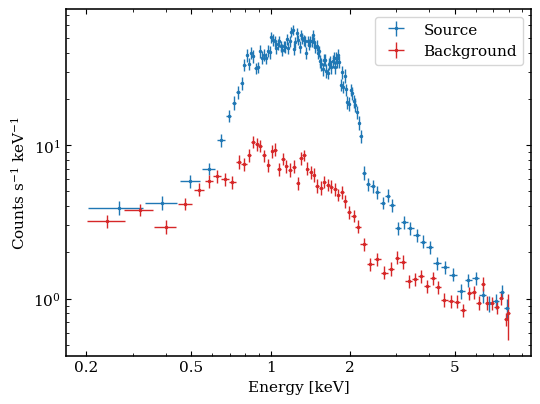

In [195]:
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(6, 4.5))
Plot.xAxis = "keV"
Plot.background = False
Plot.setRebin(minSig=10, maxBins=30)
Plot("data")

x = Plot.x(1)
y = Plot.y(1)
yerr = Plot.yErr(1)
xerr = np.diff(x) / 2
xerr = np.append(xerr, xerr[-1])  # Append the last interval width to match the length of x

ax.errorbar(x, y, xerr=xerr, yerr=yerr, ls="", capsize=0, elinewidth=1, fmt='.', markersize=3, label="Source")

x = Plot.x(2)
y = Plot.y(2)
yerr = Plot.yErr(2)
xerr = np.diff(x) / 2
xerr = np.append(xerr, xerr[-1])  # Append the last interval width to match the length of x

ax.errorbar(x, y, xerr=xerr, yerr=yerr, ls="", capsize=0, elinewidth=1, fmt='.', markersize=3, label=f"Background", color="C3")

ax.set_xlabel("Energy [keV]")
ax.set_ylabel(r"$\mathrm{Counts\ s^{-1}\ keV^{-1}}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()

# Set custom ticks and labels
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_xticks([0.2, 0.5, 1, 2, 5])
ax.set_xticklabels(['0.2', '0.5', '1', '2', '5'])
fig.savefig(f"{output_dir}/SRC_BKG_spectrum.png", dpi=300, bbox_inches="tight")

In [196]:
AllModels.clear()
Xset.chatter = 1
m_src = Model(modelname, "src", 1)  # define model for src1 and name it "src"
m_bkg = Model("constant*(apec+TBabs(apec+apec+powerlaw))", "bkg", 2)  # define model for src2 and name it "bkg"
Xset.restore(f"{Dir}/TM8_FWC_c010_mod_customized_src.dat")  # load fwc model from the file
m_fwc = AllModels(1, "fwc")  # point the "fwc" model from data group 1 to the variable m_fwc

# to set all parameters of fwc frozon, except the constant.
for _name in m_fwc.componentNames:
    if _name != "constant":
        _comp = m_fwc.__getattribute__(_name)
        for _pname in _comp.parameterNames:
            _par = _comp.__getattribute__(_pname)
            _par.frozen = True


***Warning: The file sent to Xset.restore(): ../Data/Spectra//TM8_FWC_c010_mod_customized_src.dat
    is not detected to be a file generated from Xset.save().
    Xset.restore() usage is only intended for Xset.save() output.
    General XSPEC/Tcl scripts may not fully execute in PyXspec.




In [197]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model bkg:constant<1>(apec<2> + TBabs<3>(apec<4> + apec<5> + powerlaw<6>)) Source No.: 2   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   constant   factor              1.00000      +/-  0.0          
   2    2   apec       kT         keV      1.00000      +/-  0.0          
   3    2   apec       Abundanc            1.00000      frozen
   4    2   apec       Redshift            0.0          frozen
   5    2   apec       norm                1.00000      +/-  0.0          
   6    3   TBabs      nH         10^22    1.00000      +/-  0.0          
   7    4   apec       kT         keV      1.00000      +/-  0.0          
   8    4   apec       Abundanc            1.00000      frozen
   9    4   apec       Redshift            0.0          frozen
  10    4   apec       norm                1.00000      +/-  0.0          
  11    5   apec       kT         keV      1.00000      +/-  0.0          
  12    5   apec       Abundanc          

In [198]:
# Load values from xcm file
def parse_xspec_model_file(xcm_file, model_name='bkg'):
    """Parse XSPEC model file and extract parameter values for a specific model"""
    params = []
    in_model = False
    
    with open(xcm_file, 'r') as f:
        for line in f:
            # Check if we're in the right model section
            if f'model  ' in line and model_name in line:
                in_model = True
                continue
            
            # Stop reading if we hit another model definition
            if in_model and line.strip().startswith('model  ') and model_name not in line:
                break
            
            # Extract parameter values (first column of numbers after model definition)
            if in_model and line.strip() and not line.startswith('#'):
                try:
                    # Try to parse the first value as a float
                    value = float(line.split()[0])
                    params.append(value)
                except (ValueError, IndexError):
                    # Skip lines that don't start with a number
                    continue
    
    return params

# Load background model parameters from xcm file
xcm_file = f'{Dir}/Fitting_Results/BKG_apec_tbabs_apec_apec_po/bkg_xspec_model.xcm'
bkg_params = parse_xspec_model_file(xcm_file, 'bkg')

# Extract values and set them to the respective parameters
m_bkg.constant.factor.values = [1, 0.1, 1/2, 1/2, 1*2, 1*2]
m_bkg.apec.kT = bkg_params[0]
m_bkg.apec.norm = bkg_params[3]
m_src.TBabs.nH = bkg_params[4]
m_bkg.TBabs.nH = bkg_params[4]
m_bkg.apec_4.kT = bkg_params[5]
m_bkg.apec_4.norm = bkg_params[8]
m_bkg.apec_5.kT = bkg_params[9]
m_bkg.apec_5.norm = bkg_params[12]
m_bkg.powerlaw.PhoIndex = bkg_params[13]
m_bkg.powerlaw.norm = bkg_params[14]

fwc_params = parse_xspec_model_file(xcm_file, 'fwc')
m_fwc.constant.factor.values = [fwc_params[0], 0.1, fwc_params[0]/2, 
                                fwc_params[0]/2, fwc_params[0]*2, 
                                fwc_params[0]*2]

In [199]:
m_bkg.constant.factor.frozen = False
m_fwc.constant.factor.frozen = False

m_bkg.apec.kT.frozen = True
m_bkg.apec.norm.frozen = True
m_bkg.TBabs.nH.frozen = True
m_bkg.apec_4.kT.frozen = True
m_bkg.apec_4.norm.frozen = True
m_bkg.apec_5.kT.frozen = True
m_bkg.apec_5.norm.frozen = True
m_bkg.powerlaw.PhoIndex.frozen = True
m_bkg.powerlaw.norm.frozen = True

In [200]:
m_src.TBabs.nH.frozen = False
# m_src.vpshock.Tau_u = 1e8
# m_src.vnei.Tau = 1e8

In [201]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model bkg:constant<1>(apec<2> + TBabs<3>(apec<4> + apec<5> + powerlaw<6>)) Source No.: 2   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   constant   factor              1.00000      +/-  0.0          
   2    2   apec       kT         keV      0.201866     frozen
   3    2   apec       Abundanc            1.00000      frozen
   4    2   apec       Redshift            0.0          frozen
   5    2   apec       norm                2.28122E-03  frozen
   6    3   TBabs      nH         10^22    0.527875     frozen
   7    4   apec       kT         keV      0.250000     frozen
   8    4   apec       Abundanc            1.00000      frozen
   9    4   apec       Redshift            0.0          frozen
  10    4   apec       norm                5.00760E-16  frozen
  11    5   apec       kT         keV      0.734139     frozen
  12    5   apec       Abundanc            1.00000      frozen
  13    5   apec       Redshift            0.0    

In [202]:
Xset.chatter = 10
Fit.query = "yes"
Fit.nIterations = 1000
Fit.perform()
Xset.chatter = 1

                                   Parameters
C-Statistic  |beta|/N    Lvl      src:1:nH      src:2:kT  src:17:Tau_u   src:19:norm src:20:PhoInd   src:21:norm  bkg:1:factor  fwc:1:factor
3298.56      4220.46      -3      0.748625      0.132716   3.63471e+11     0.0387590       2.55282     0.0983972      0.994129       1.20782
1801.91      3404.83      -4      0.629346      0.114416   2.36224e+10     0.0105494       2.12728      0.120416      0.998703       1.17442
1723.57      252.755      -5      0.790902     0.0920101   1.06192e+10       2.36640       2.36941      0.155941       1.00006       1.16841
1704.88      251.429      -6      0.818149     0.0823259   3.04949e+09       17.1057       2.38927      0.165842      0.999864       1.16807
1675.42      195.338      -1      0.826626     0.0815195   1.19736e+08       17.1882       2.38366      0.166453      0.999512       1.16841
1672.9       44.8715      -1      0.835620     0.0808887   1.06181e+08       17.6691       2.39179      0.16

In [203]:
stat = Fit.statistic
dof = Fit.dof
stat/dof

1.0814186457393975

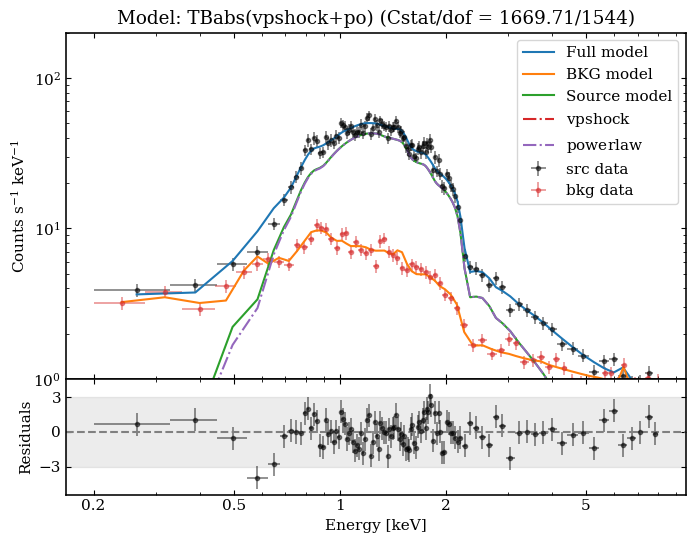

In [204]:
Plot.device = "/null"
Plot.add = True
Plot.xAxis = "keV"
Plot.setRebin(minSig=10, maxBins=30)
Plot('ldata delchi')
total_model = Plot.model(1)
src_data = Plot.y(1)
bkg_data = Plot.y(2)
eng_src= Plot.x(1)
eng_bkg= Plot.x(2)
res_src = Plot.y(1, 2)
res_src_err = Plot.yErr(1, 2)


if Plot.nAddComps(2) < Plot.nAddComps(1):
    apec1 = np.array(Plot.addComp(1, 1))
    apec2 = np.array(Plot.addComp(2, 1)) 
    total_src = apec1 + apec2
    bkg_model = Plot.model(2)
if Plot.nAddComps(2) == Plot.nAddComps(1):
    bkg_model = np.zeros(len(Plot.model(1)))
    for i in range(1, Plot.nAddComps()+1):
        bkg_model += np.array(Plot.addComp(i, 1))
    apec1 = total_model - bkg_model

# Pib_model = np.zeros(len(Plot.model(2)))
# for i in range(5, Plot.nAddComps()+1):
#     Pib_model += np.array(Plot.addComp(i, 2))

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}, figsize=(8, 6))

# Plot the data and models
ax1.errorbar(eng_src, src_data, xerr=Plot.xErr(1), yerr=Plot.yErr(1), fmt='.', color="black", label="src data", alpha=0.5, lw=1.2)
ax1.errorbar(eng_bkg, bkg_data, xerr=Plot.xErr(2), yerr=Plot.yErr(2), fmt='.', color="C3", label="bkg data", alpha=0.5, lw=1.2)
ax1.plot(eng_src, total_model, label="Full model")

if Plot.nAddComps(2) < Plot.nAddComps(1):
    ax1.plot(eng_bkg, bkg_model, label="BKG model")
    ax1.plot(eng_src, total_src, label="Source model")
    ax1.plot(eng_src, apec1, label=r"$\mathrm{vpshock}$", linestyle="-.")
    ax1.plot(eng_src, apec2, label=r"$\mathrm{powerlaw}$", linestyle="-.")
    # ax1.plot(eng_src, apec1, label=r"$\mathrm{vapec}$", linestyle="-.")
else:
    ax1.plot(eng_src, bkg_model, label="BKG model")
    ax1.plot(eng_src, apec1, label=r"$\mathrm{powerlaw}$", linestyle="-")
ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_ylabel(r"$\mathrm{Counts\ s^{-1}\ keV^{-1}}$")
ax1.set_ylim(1, 2e2)
ax1.legend()

# Plot the residuals
ax2.errorbar(eng_src, res_src, xerr=Plot.xErr(1), yerr=res_src_err, fmt='.', color="black", label="src residuals", alpha=0.5, lw=1.2)
ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xscale("log")
ax2.set_xlabel("Energy [keV]")
ax2.set_ylabel("Residuals")
ax2.set_xticks([0.2, 0.5, 1, 2, 5])
ax2.set_xticklabels(['0.2', '0.5', '1', '2', '5'])
ax2.set_yticks([-3, 0, 3]) 
ax2.axhspan(-3, 3, color='gray', alpha=0.15)
ax1.set_title(f'Model: {modelname} (Cstat/dof = {stat:.2f}/{dof})')

fig.savefig(f"{output_dir}/PySpec_fitting.png", dpi=300, bbox_inches="tight")

In [205]:
if os.path.exists(f'{output_dir}/src_xspec_model.xcm'):
    os.remove(f'{output_dir}/src_xspec_model.xcm')
Xset.save(f'{output_dir}/src_xspec_model.xcm')